# 0) Importing libraries and loading/cleaning dat

In [1]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate
from scipy.io import loadmat

In [2]:
#Try to load cleaned data, clean it if it isn't there. (15.82% of data was tossed doing this)
try:
    df = pd.read_pickle("pioneer_data.pkl")
except:

    #Filename input, and initializing lists for dataclean outputs
    filenames = [
        "Transfer_Pioneer_6_v3.mat",
        "Transfer_Pioneer_7_v3.mat",
        "Transfer_Pioneer_8_v3.mat"
    ]
    
    dfs = []
    all_metadata = {}
    
    #data reorganization loop
    for path in filenames:
        
        mat = loadmat(path)
        #filter matlab internal fields
        mat = {k: v for k, v in mat.items() if not k.startswith("__")}
        #squeeze arrays
        mat = {k: np.squeeze(v) for k, v in mat.items()}
        #get length of each dataframe to separate variables and metadata
        lengths = {k: np.size(v) for k, v in mat.items() if isinstance(v, np.ndarray)}
        target_len = max(set(lengths.values()), key=list(lengths.values()).count)
    
        #initialize dictionaries for both and loop through each key in the dictionary
        data = {}
        metadata = {}
        for k, v in mat.items():
            if isinstance(v, np.ndarray) and np.size(v) == target_len:
                data[k] = np.ravel(v)
            else:
                metadata[k] = v
    
        #turn variables into dataframe
        df = pd.DataFrame(data)
        #convert from MATLAB time to datetime
        if "mtime" in df:
            df["time"] = pd.to_datetime(df["mtime"] - 719529, unit="D")
        df["source_file"] = path
        dfs.append(df)
        all_metadata[path] = metadata
    
    # combine all files
    df = pd.concat(dfs, ignore_index=True)
    
    #get metadata
    df.attrs["metadata"] = all_metadata
    metadata_dict = df.attrs["metadata"]
    # Convert nested dictionary into a DataFrame
    meta_df = pd.DataFrame.from_dict(metadata_dict, orient='index')
    # Flatten single-value arrays into scalars
    meta_df = meta_df.map(lambda x: x.item() if isinstance(x, np.ndarray) else x)
    # Reset index so filenames are a column
    meta_df = meta_df.reset_index().rename(columns={'index': 'source_file'})
    df = df.merge(meta_df, on="source_file", how="left")
    
    #Get Julian day of the year
    df["yday"] = df["time"].dt.dayofyear 
    
    nonzero = (df['Sbytes'] != 0).sum()
    print(f"Percentage of the data that is not high quality: {100 * (nonzero / df.shape[0]):.2f}%")

# Problem 1)

Download the COARE v3.6 algorithm in your preferred language (Matlab, Python, or Fortran) from https://github.com/NOAA-PSL/COARE-algorithm. Familiarize yourself with the code.

In [3]:
import sys
sys.path.append('./COARE3_6')
#This is the version with warm layer computations
from COARE3_6.coare36vnWarm_et import *
from COARE3_6.coare36vnWarm_et import coare36vnWarm_et as COARE

---

# Problem 2)

COARE v3.6 offers three parameterizations of roughness length (See Edon et al. 2013). Compute roughness length, drag coefficient, and wind stress using these three formulations

#### Variable name tracker:

| Input | Required? | Units | Description / Notes |
|-------|-----------|-------|-------------------|
| `Jd` | Yes | days | Julian day / day of year |
| `U` | Yes | m/s | Wind speed relative to water at height `Zu` |
| `Zu` | Yes | m | Wind measurement height |
| `Tair` | Yes | °C | Air temperature at height `Zt` |
| `Zt` | Yes | m | Air temperature measurement height |
| `RH` | Yes | % | Relative humidity at height `Zq` |
| `Zq` | Yes | m | Humidity measurement height |
| `P` | Yes | mb | Air pressure at sea level |
| `Tsea` | Yes | °C | Surface/bulk sea temperature at depth `Ts_depth` |
| `SW_dn` | Optional | W/m² | Downward shortwave radiation; positive = ocean warming |
| `LW_dn` | Optional | W/m² | Downward longwave radiation; positive = ocean warming |
| `Lat` | Optional | deg | Latitude (positive north) |
| `Lon` | Optional | deg | Longitude (positive east) |
| `Zi` | Optional | m | Inversion / PBL height; default can be 600 m |
| `Rainrate` | Optional | mm/hr | Rain rate; can use NaN if unavailable |
| `Ts_depth` | Yes | m | Depth of the water temperature measurement below surface |
| `Ss` | Optional | PSU | Sea surface salinity |
| `cp` | Optional | m/s | Phase speed of dominant waves |
| `sigH` | Optional | m | Significant wave height |
| `zrf_u` | Optional | m | Reference height for wind profile (default 10 m) |
| `zrf_t` | Optional | m | Reference height for temperature profile (default 10 m) |
| `zrf_q` | Optional | m | Reference height for humidity profile (default 10 m) |


In [4]:
#drop NaN values
#replace NaN values with zeros so COARE can run
df['rain'] = df['rain'].fillna(0) #rainfall rate

df = df.dropna().copy()

Jd = df["yday"].to_numpy()  # Julian Day
U = df['Ur'].to_numpy()  # Vector averaged wind speed relative to water (m/s) at zu
Zu = df['zu'].to_numpy()  # Height of anemometer (m)
Tair = df['Tair'].to_numpy()  # Air temperature (C) at zt
Zt = df['zt'].to_numpy()  # Height of thermometer (m)
RH = df['RH'].to_numpy()  # Relative humidity (%) at zq
Zq = df['zq'].to_numpy()  # Height of hygrometer (m)
P = df['Pair'].to_numpy()  # Air pressure (mb)
Tsea = df['Tsea'].to_numpy()  # Bulk sea temperature (C)
SW_dn = df['Solar'].to_numpy()  # Downwelling solar radiation (W/m2)
LW_dn = df['IR'].to_numpy()  # Downwelling IR radiation (W/m2)
Lat = df['lat'].to_numpy()  # Latitude
Lon = df['lon'].to_numpy()  # Longitude
Zi = df['zi'].to_numpy()  # Height of inversion (m)
Rainrate = df['rain'].to_numpy()  # Rain rate (mm/hour)
Ss = df['SSQ'].to_numpy()  # Sea surface specific humidity (g/kg)
cp = df['cp'].to_numpy()  # Phase speed of dominant waves (m/s)
sigH = df['sigH'].to_numpy()  # Significant wave height (m)


#Put in 0 meters for water depth since the warm skin correction has already been applied
df['Ts_depth'] = 0.0
Ts_depth = df['Ts_depth'].to_numpy() 

#For later formulations
Tm = df['Tm'] #Mean period of waves (s) from zero crossings

data = df.copy().reset_index()

## Running COARE

In [5]:
#COARE Output labels
coare_columns = [
    "usr", "tau", "hsb", "hlb", "hbb", "hsbb", "hlwebb", "tsr", "qsr",
    "zo", "zot", "zoq", "Cd", "Ch", "Ce", "L", "zeta", "dT_skinx", "dq_skinx", "dz_skin",
    "Urf", "Trf", "Qrf", "RHrf", "UrfN", "TrfN", "QrfN",
    "lw_net", "sw_net", "Le", "rhoa", "UN", "U10", "U10N", "Cdn_10", "Chn_10", "Cen_10",
    "hrain", "Qs", "Evap", "T10", "T10N", "Q10", "Q10N", "RH10", "P10", "rhoa10",
    "gust", "wc_frac", "Edis",
    "dT_warm",  "dz_warm",  "dT_warm_to_skin",  "du_warm"
]

In [6]:
#Wave-age roughness
#See if it's been saved already, if not run COARE
try:
    wind = pd.read_pickle("wind_data.pkl")
except:
    #Run COARE with the wind based formulation
    wind_arr = COARE(
        Jd=Jd,
        U=U,
        Zu=Zu,
        Tair=Tair,
        Zt=Zt,
        RH=RH,
        Zq=Zq,
        P=P,
        Tsea=Tsea,
        SW_dn=SW_dn,
        LW_dn=LW_dn,
        Lat=Lat,
        Lon=Lon,
        Zi=Zi,
        Rainrate=Rainrate,
        Ts_depth=Ts_depth,
        Ss=Ss,
        cp=None,
        sigH=None
    )
    wind = pd.DataFrame(wind_arr, columns=coare_columns)


In [7]:
#Wave-age roughness
#See if it's been saved already, if not run COARE
try:
    wave = pd.read_pickle("wave_data.pkl")
except:
    wave_arr = COARE(
        Jd=Jd,
        U=U,
        Zu=Zu,
        Tair=Tair,
        Zt=Zt,
        RH=RH,
        Zq=Zq,
        P=P,
        Tsea=Tsea,
        SW_dn=SW_dn,
        LW_dn=LW_dn,
        Lat=Lat,
        Lon=Lon,
        Zi=Zi,
        Rainrate=Rainrate,
        Ts_depth=Ts_depth,
        Ss=Ss,
        cp=cp,
        sigH=None
    )
    wave = pd.DataFrame(wind_arr, columns=coare_columns)

In [8]:
try:
    sea = pd.read_pickle("sea_data.pkl")
    
except:
    #Sea state 
    sea_arr = COARE(
        Jd=Jd,
        U=U,
        Zu=Zu,
        Tair=Tair,
        Zt=Zt,
        RH=RH,
        Zq=Zq,
        P=P,
        Tsea=Tsea,
        SW_dn=SW_dn,
        LW_dn=LW_dn,
        Lat=Lat,
        Lon=Lon,
        Zi=Zi,
        Rainrate=Rainrate,
        Ts_depth=Ts_depth,
        Ss=Ss,
        cp=cp,
        sigH=sigH
    )
    sea = pd.DataFrame(wind_arr, columns=coare_columns)


## Calculations for Problem 3

Equation 12: 
$$
z_{rough} =  H_s \cdot D \left( \frac{u_*}{c_p} \right)^{B}
$$

Where:
 - $D=0.39$
 - $B=2.6$

In [9]:
g = 9.81 #m/s^2
#calculate mean phase speed
cm = g * Tm / (2 * np.pi)
cm = cm.to_numpy()

Code that went into my COARE function:

```python
if zo_mode == 12:
    D12 = 0.39
    B12 = 2.6
    valid = (~np.isnan(cm)) & (~np.isnan(sigH)) & (cm > 0)
    
    zo12 = sigH * D12 * (usr / cm) ** B12
    charn12 = zo12 * grav / usr**2

    charn = charnC.copy()
    charn[valid] = charn12[valid]

elif zo_mode == 13:
    a13 = 0.4
    b13 = 0.32
    
    D13 = 0.09
    B13 = 2
    valid = (~np.isnan(cm)) & (~np.isnan(sigH)) & (cm > 0)
    
    zo13 = sigH * D13 * np.cos(a13 * theta) * (usr / cm) ** (B13 * np.cos(b13 * theta))
    charn13 = zo13 * grav / usr**2

    charn = charnC.copy()
    charn[valid] = charn13[valid]
    
else:
    charn = charnC.copy()
    zoS = sigH * Ad * (usr / cm) ** Bd
    charnS = zoS * grav / usr**2
    ii = ~np.isnan(cp)
    charn[ii] = charnS[ii]
```

In [10]:


#See if precalculated file is there, calculate if not
try:
    eq12 = pd.read_pickle("eq12_data.pkl")
    
except:
    #Equation 12
    eq12_arr = COARE(
        Jd=Jd,
        U=U,
        Zu=Zu,
        Tair=Tair,
        Zt=Zt,
        RH=RH,
        Zq=Zq,
        P=P,
        Tsea=Tsea,
        SW_dn=SW_dn,
        LW_dn=LW_dn,
        Lat=Lat,
        Lon=Lon,
        Zi=Zi,
        Rainrate=Rainrate,
        Ts_depth=Ts_depth,
        Ss=Ss,
        cp=cp,
        sigH=sigH,
        zo_mode=12,
        Cm=cm,
        Theta=np.zeros(U.shape[0])
    )
    eq12 = pd.DataFrame(eq12_arr, columns=coare_columns)

eq12.to_pickle('eq12_data.pkl')

Equation 13:

$$
z_{rough} =  H_s  D \cdot cos(a \theta) \left( \frac{u_*}{c_p} \right)^{Bcos(b \theta)}
$$

In [11]:
Wdir_to = (data['Wdir'] + 180) % 360

# Relative angle: wind minus waves
angle_diff = (Wdir_to - data['sigHDir'] + 180) % 360 - 180  # gives -180 to 180 range
angle_diff = angle_diff.to_numpy()
angle_diff = -1 * np.abs(angle_diff)  + angle_diff.max()
theta = np.deg2rad(angle_diff)


#See if precalculated file is there, calculate if not
try:
    eq13 = pd.read_pickle("eq13_data.pkl")
    
except:
    #Equation 13
    eq13_arr = COARE(
        Jd=Jd,
        U=U,
        Zu=Zu,
        Tair=Tair,
        Zt=Zt,
        RH=RH,
        Zq=Zq,
        P=P,
        Tsea=Tsea,
        SW_dn=SW_dn,
        LW_dn=LW_dn,
        Lat=Lat,
        Lon=Lon,
        Zi=Zi,
        Rainrate=Rainrate,
        Ts_depth=Ts_depth,
        Ss=Ss,
        cp=cp,
        sigH=sigH,
        zo_mode=13,
        Cm=cm,
        Theta=theta
    )
    eq13 = pd.DataFrame(eq13_arr, columns=coare_columns)

---
## Making plots

In [12]:
#Setting up lists for plots
out1 = ['zo', 'Cd', 'tau']
ylabels = [r'Roughness length ($z_0$)', r'Drag Coefficient ($C_d$)', r'Wind Stress ($\tau$)']

labels = ['Wind based', 'Wave age based', 'Sea state based', 'Mean wave period based', 'Wave misalignment based']
dfs = [wind, wave, sea, eq12, eq13]

#add datetime columns
for frame in dfs:
    frame['time'] = data['time']

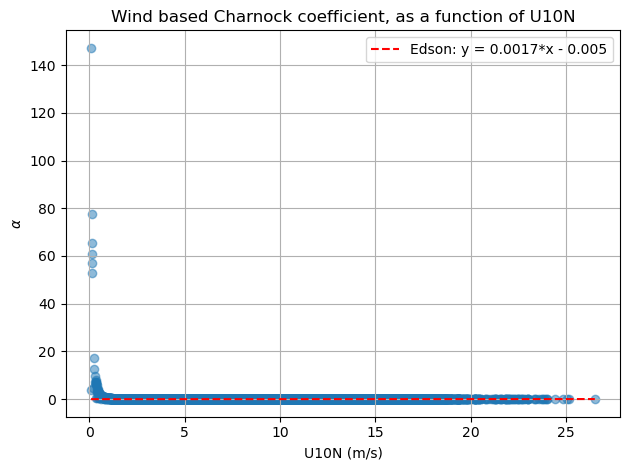

In [13]:
g = 9.81  # m/s^2
wind['charnock'] = wind['zo'] * g / wind['usr']**2

plt.plot()

plt.scatter(wind['U10N'], wind['charnock'], alpha=0.5)

m = 0.0017
b = -0.005
x_vals = np.linspace(wind['U10N'].min(), wind['U10N'].max(), 100)
y_vals = m * x_vals + b
plt.plot(x_vals, y_vals, 'r--', label='Edson: y = 0.0017*x - 0.005')  # red dashed line

plt.xlabel('U10N (m/s)')
plt.ylabel(r'\alpha')
plt.ylabel(r'$\alpha$')
plt.title("Wind based Charnock coefficient, as a function of U10N")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

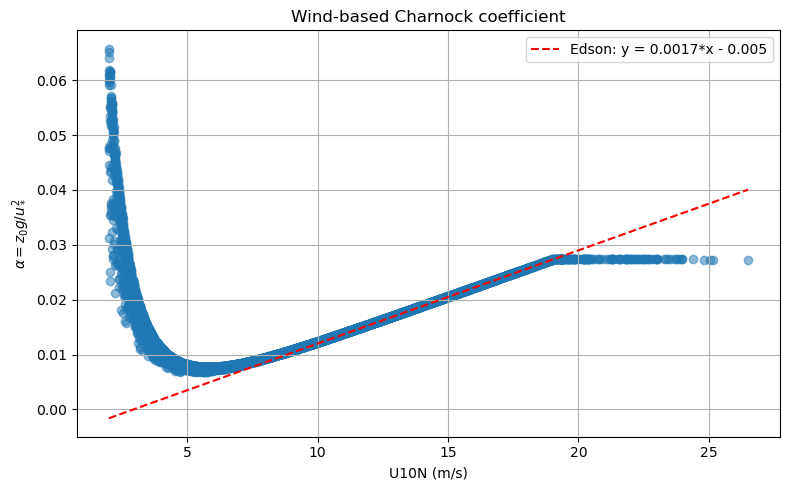

In [14]:
#filter out low x values
mask = wind['U10N'] > 2
U10N_filtered = wind['U10N'][mask]
charnock_filtered = wind['charnock'][mask]

plt.figure(figsize=(8,5))
plt.scatter(U10N_filtered, charnock_filtered, alpha=0.5)

# y = mx + b line
m = 0.0017
b = -0.005
x_vals = np.linspace(U10N_filtered.min(), U10N_filtered.max(), 100)
y_vals = m * x_vals + b
plt.plot(x_vals, y_vals, 'r--', label='Edson: y = 0.0017*x - 0.005')

plt.xlabel('U10N (m/s)')
plt.ylabel(r'$\alpha = z_0g/u_*^2$')
plt.title("Wind-based Charnock coefficient")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

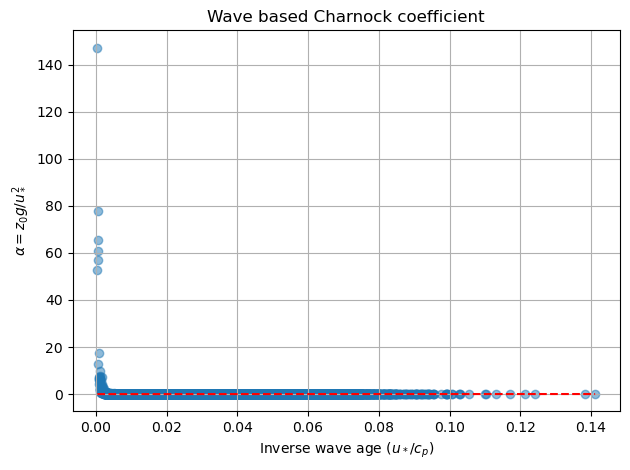

In [15]:
A = 0.114
B = 0.622

wave['charnock'] = wave['zo'] * g / wave['usr']**2

#inverse wave age
iwa = wave['usr'] / data['cp']

plt.plot()

plt.scatter(iwa, wave['charnock'], alpha=0.5)

x_vals = np.linspace(iwa.min(), iwa.max(), 100)
y_vals = A * (x_vals) ** B
plt.plot(x_vals, y_vals, 'r--', label=r'$A(u_*/c_p)^B$')  # red dashed line
plt.xlabel(r'Inverse wave age ($u_*/c_p$)')
plt.ylabel(r'$\alpha = z_0g/u_*^2$')
plt.title("Wave based Charnock coefficient")
plt.grid(True)

plt.tight_layout()
plt.show()

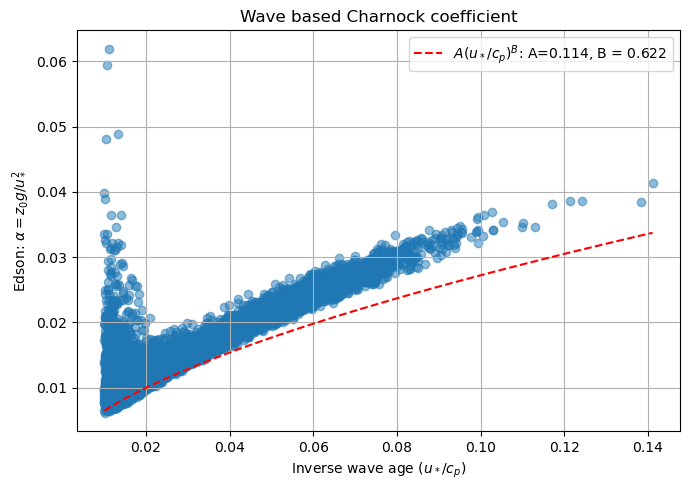

In [16]:
# Edson et al. 2013 parameters
A = 0.114
B = 0.622

# Inverse wave age
iwa = wave['usr'] / data['cp']

# Filter for iwa > 0.01
mask = iwa > 0.01
iwa_filtered = iwa[mask]
charnock_filtered = wave['charnock'][mask]

plt.figure(figsize=(7,5))

# Scatter with filter applied
plt.scatter(iwa_filtered, charnock_filtered, alpha=0.5)

# Edson line
x_vals = np.linspace(iwa_filtered.min(), iwa_filtered.max(), 100)
y_vals = A * x_vals**B
plt.plot(x_vals, y_vals, 'r--', label=r'$A(u_*/c_p)^B$: A=0.114, B = 0.622')  # red dashed line

plt.xlabel(r'Inverse wave age ($u_*/c_p$)')
plt.ylabel(r'Edson: $\alpha = z_0g/u_*^2$')
plt.title("Wave based Charnock coefficient")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

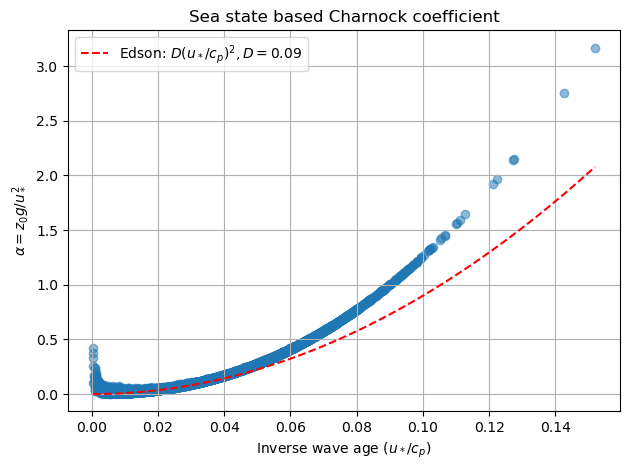

In [17]:
# Edson et al. 2013 parameters
D = 0.09

#Mirroring Edson et al. Figure 8
x = sea['usr'] / data['cp']
y = sea['zo'] / data['sigH'] * 1000

# Filter for iwa > 0.01
mask = x > 0.0
x_filtered = x[mask]
y_filtered = y[mask]


plt.figure()

# Scatter with filter applied
plt.scatter(x_filtered, y_filtered, alpha=0.5)

# Edson line
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = (D * x_vals**2) *1000
plt.plot(x_vals, y_vals, 'r--', label=r'Edson: $D(u_*/c_p)^2, D=0.09$')  # red dashed line

plt.xlabel(r'Inverse wave age ($u_*/c_p$)')
plt.ylabel(r'$\alpha = z_0g/u_*^2$')
plt.title("Sea state based Charnock coefficient")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

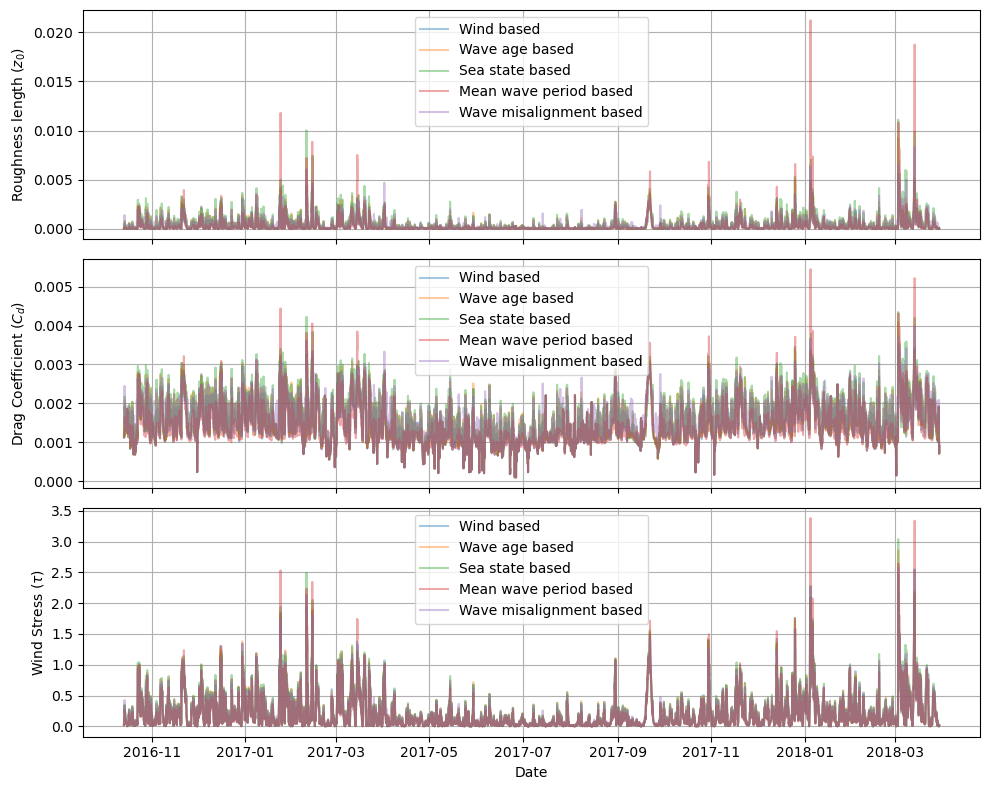

In [18]:
# Make time series
fig, axes = plt.subplots(len(out1), 1, figsize=(10, 8), sharex=True)

for i, var in enumerate(out1):
    ax = axes[i]
    
    for j, (df, label) in enumerate(zip(dfs, labels)):
        # Set lower alpha for third (sea) line
        alpha = 0.4
        ax.plot(df['time'], df[var].values, label=label, alpha=alpha)  
        
    ax.set_ylabel(ylabels[i])
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

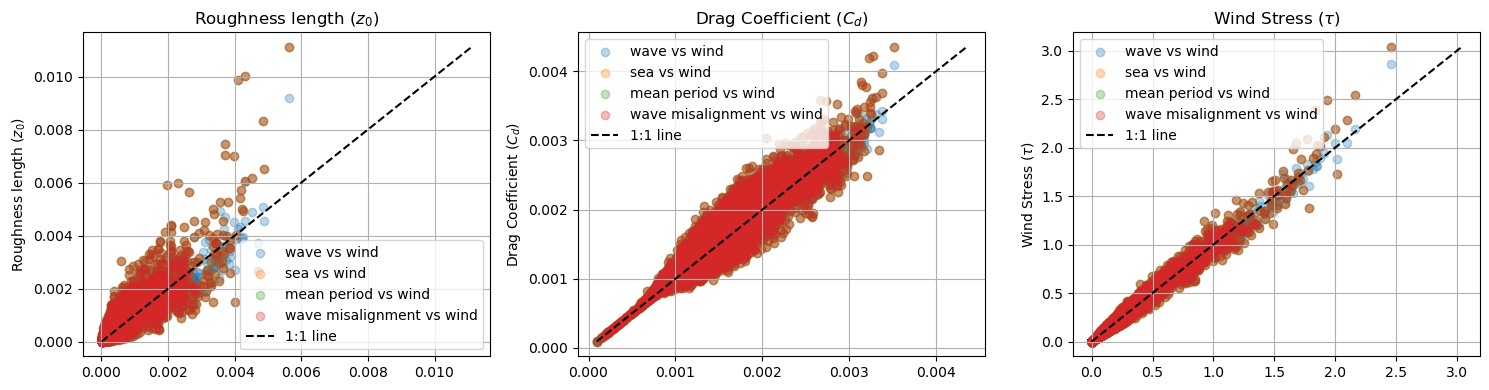

In [19]:
fig, axes = plt.subplots(1, len(out1), figsize=(15, 4))

# organize your comparisons
comparisons = [
    (wave, 'wave vs wind', 0.3),
    (sea, 'sea vs wind', 0.3),
    (sea, 'mean period vs wind', 0.3),
    (sea, 'wave misalignment vs wind', 0.3),
]

for i, var in enumerate(out1):
    ax = axes[i]

    # scatter plots
    for df, label, alpha in comparisons:
        ax.scatter(wind[var], df[var], alpha=alpha, label=label)

    # 1:1 line using ALL datasets
    all_vals = np.concatenate(
        [wind[var].values] + [df[var].values for df, _, _ in comparisons]
    )
    min_val = np.nanmin(all_vals)
    max_val = np.nanmax(all_vals)

    ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 line')

    ax.set_ylabel(ylabels[i])
    ax.set_title(ylabels[i])
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

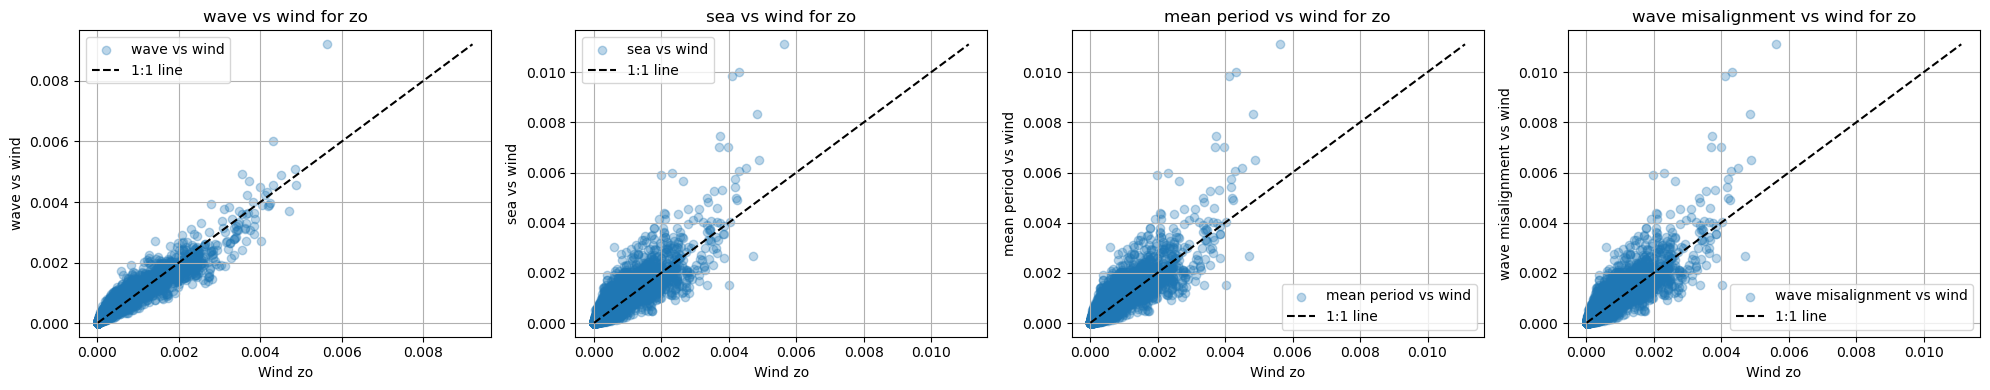

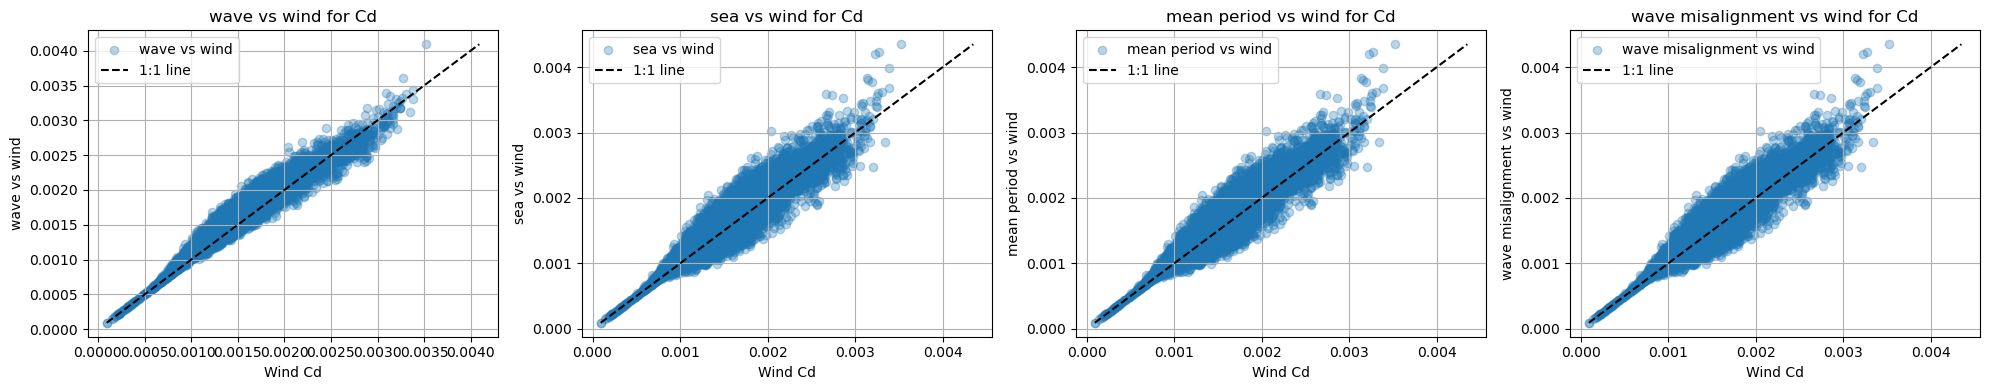

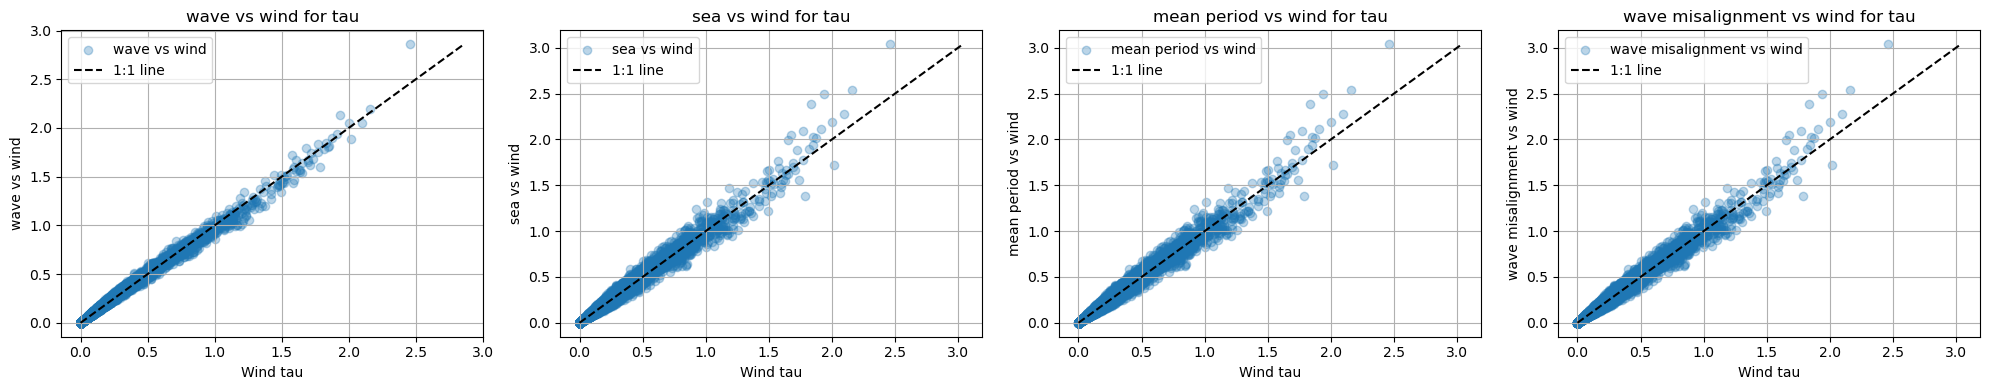

In [20]:
# organize your comparisons
comparisons = [
    (wave, 'wave vs wind', 0.3),
    (sea, 'sea vs wind', 0.3),
    (sea, 'mean period vs wind', 0.3),
    (sea, 'wave misalignment vs wind', 0.3),
]

# Loop over each variable
for i, var in enumerate(out1):
    # Create a separate figure for each variable
    fig, axes = plt.subplots(1, len(comparisons), figsize=(5 * len(comparisons), 4))
    
    if len(comparisons) == 1:
        axes = [axes]  # ensure axes is iterable if only 1 subplot

    for ax, (df, label, alpha) in zip(axes, comparisons):
        # scatter plot
        ax.scatter(wind[var], df[var], alpha=alpha, label=label)
        
        # 1:1 line using this dataset
        all_vals = np.concatenate([wind[var].values, df[var].values])
        min_val = np.nanmin(all_vals)
        max_val = np.nanmax(all_vals)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 line')
        
        ax.set_xlabel('Wind ' + var)
        ax.set_ylabel(label)
        ax.set_title(f'{label} for {var}')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

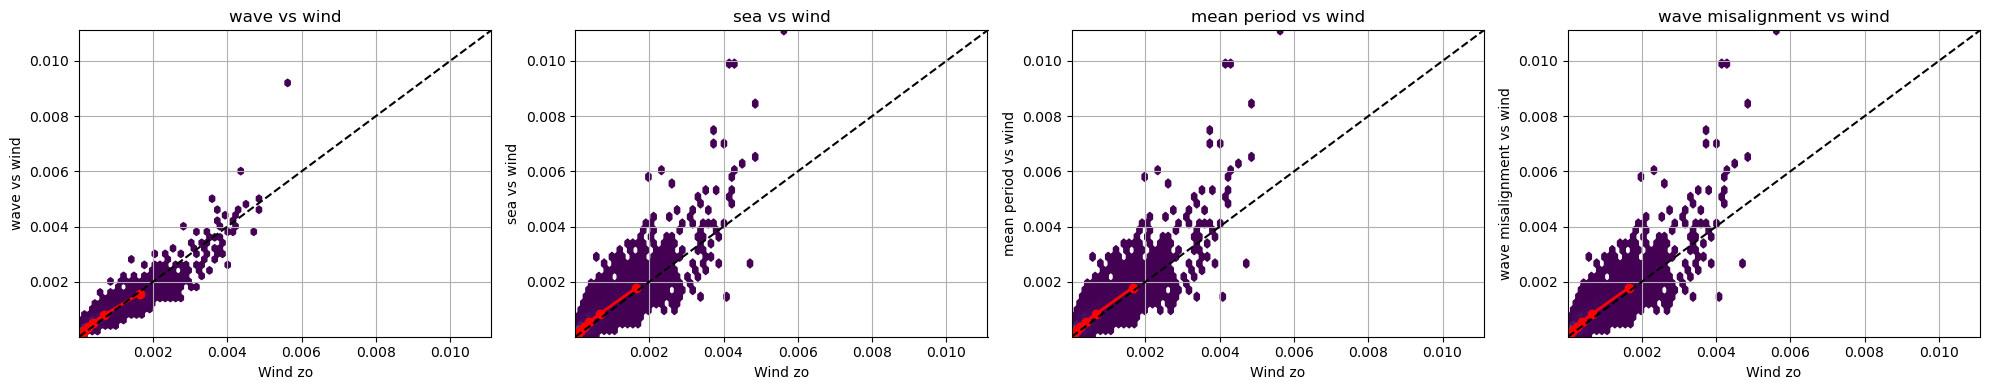

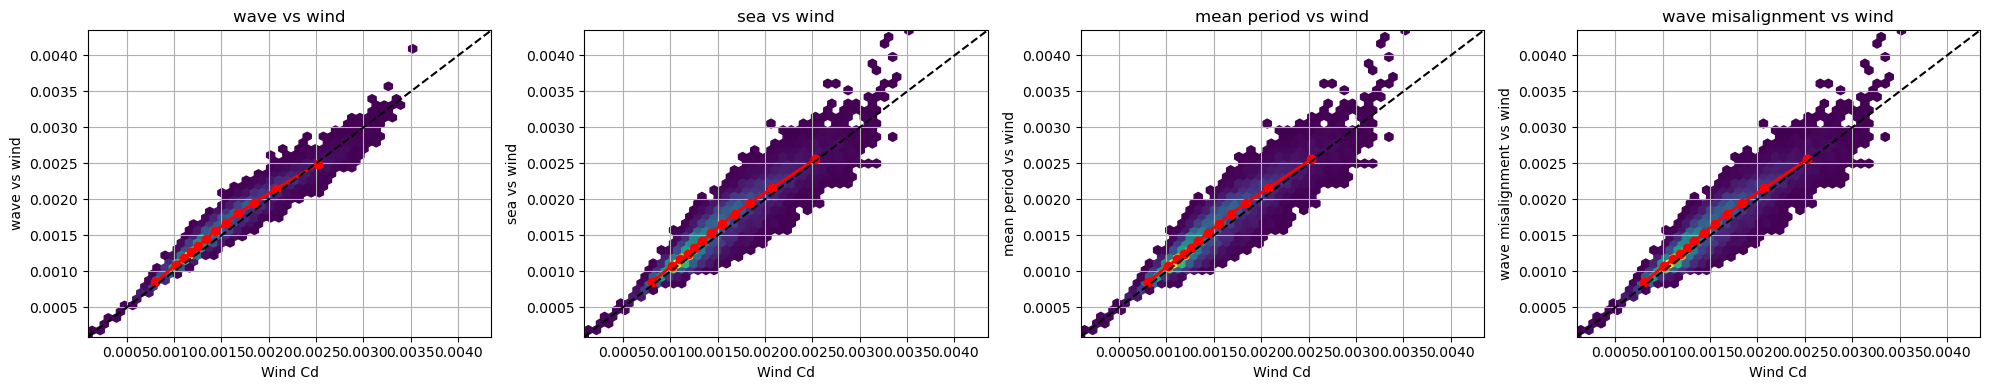

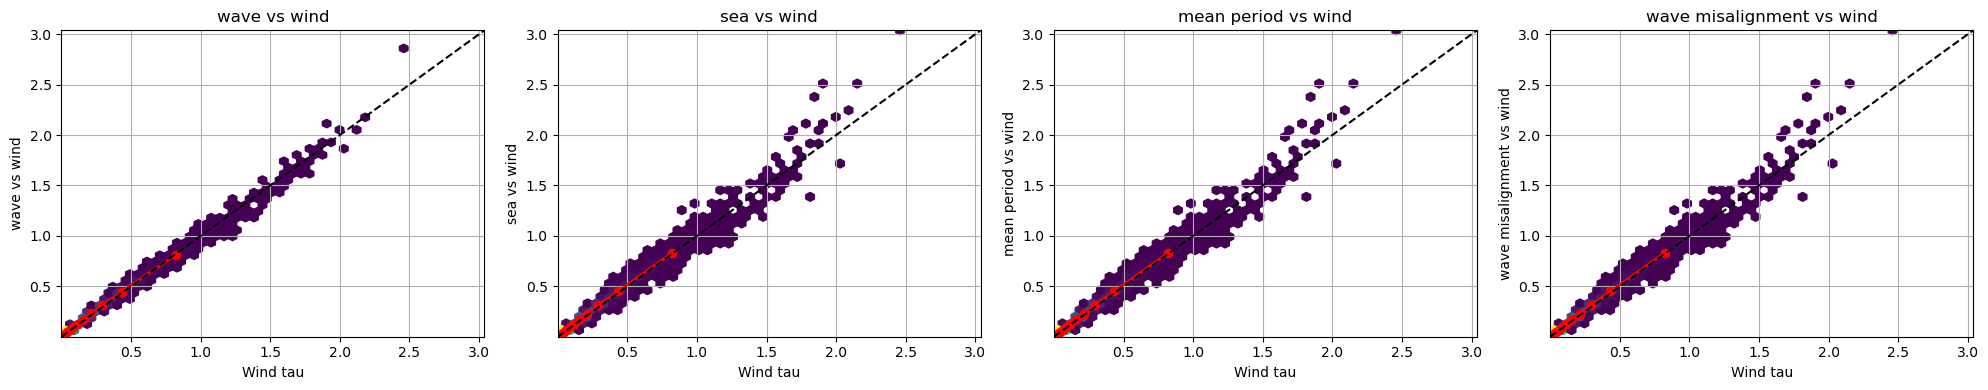

In [43]:
for i, var in enumerate(out1):
    fig, axes = plt.subplots(1, len(comparisons), figsize=(5 * len(comparisons), 4))
    
    if len(comparisons) == 1:
        axes = [axes]

    all_vals = np.concatenate([wind[var].values] + [df[var].values for df,_,_ in comparisons])
    min_val = np.nanmin(all_vals)
    max_val = np.nanmax(all_vals)

    for ax, (df, label, alpha) in zip(axes, comparisons):
        
        hb = ax.hexbin(wind[var], df[var], gridsize=40, mincnt=1)
        
        bins = pd.qcut(wind[var], 12, duplicates='drop')
        bin_centers = wind[var].groupby(bins, observed=True).mean()
        binned_mean = df[var].groupby(bins, observed=True).mean()
        ax.plot(bin_centers, binned_mean, color='red', marker='o', linewidth=2)
        
        # 1:1 line
        ax.plot([min_val, max_val], [min_val, max_val], 'k--')
        
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        
        ax.set_xlabel('Wind ' + var)
        ax.set_ylabel(label)
        ax.set_title(f'{label}')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

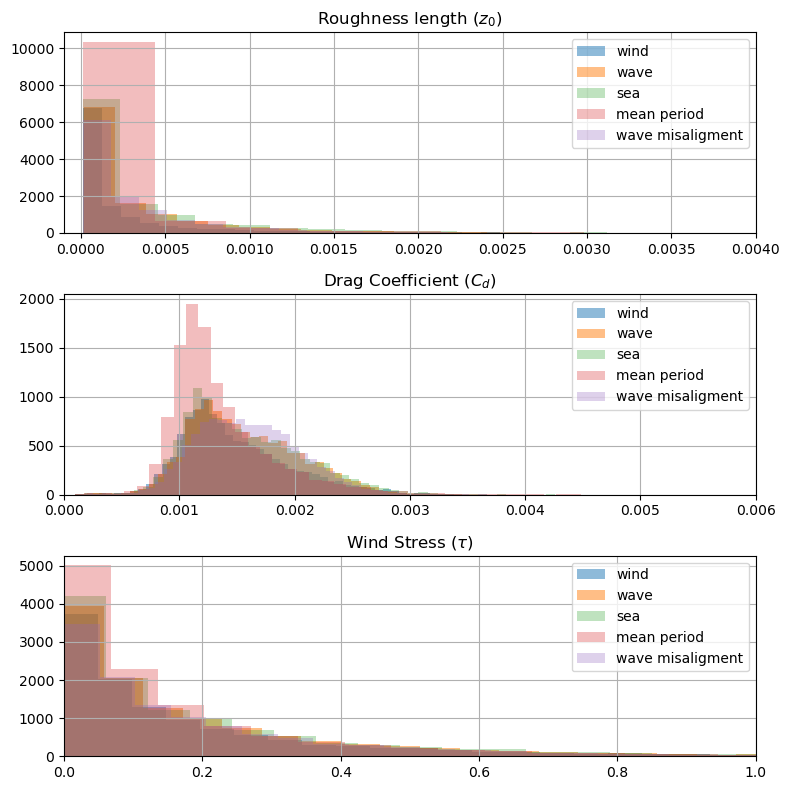

In [33]:
fig, axes = plt.subplots(len(out1), 1, figsize=(8, 8))

for i, var in enumerate(out1):
    ax = axes[i]

    if i == 0:
        ax.set_xlim(-0.0001, 0.004)
    if i == 1:
        ax.set_xlim(0, 0.006)
    if i == 2:
        ax.set_xlim(0, 1)
    
    ax.hist(wind[var], bins=50, alpha=0.5, label='wind')
    ax.hist(wave[var], bins=50, alpha=0.5, label='wave')
    ax.hist(sea[var], bins=50, alpha=0.3, label='sea')
    ax.hist(eq12[var], bins=50, alpha=0.3, label='mean period')
    ax.hist(eq13[var], bins=50, alpha=0.3, label='wave misaligment')

    
    ax.set_title(ylabels[i])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

---
# Problem 4

In [22]:
cv_tau = np.hypot(data['UWr'], data['VWr'])

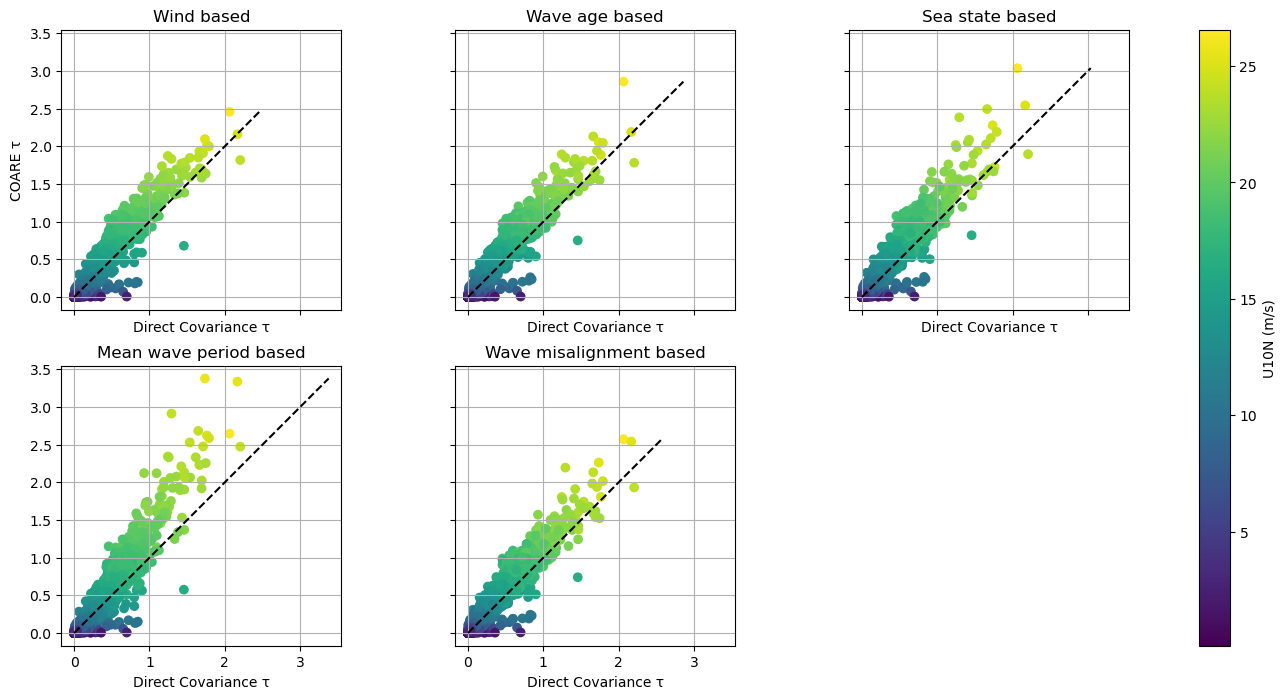

In [23]:
ncols = int(np.ceil(len(dfs) / 2))

fig, axes = plt.subplots(2, ncols, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

sc = None

for ax, df, label in zip(axes, dfs, labels):
    U10N = df['U10N']
    
    sc = ax.scatter(cv_tau, df['tau'], c=U10N, cmap='viridis')
    
    # 1:1 line
    min_val = np.nanmin([cv_tau.min(), df['tau'].min()])
    max_val = np.nanmax([cv_tau.max(), df['tau'].max()])
    ax.plot([min_val, max_val], [min_val, max_val], 'k--')
    
    ax.set_title(label)
    ax.grid(True)

for ax in axes[len(dfs):]:
    ax.remove()

fig.colorbar(sc, ax=axes[:len(dfs)], label='U10N (m/s)')
axes[0].set_ylabel('COARE τ')

for ax in axes[:len(dfs)]:
    ax.set_xlabel('Direct Covariance τ')
    ax.set_aspect('equal', adjustable='box')

#plt.tight_layout()
plt.show()

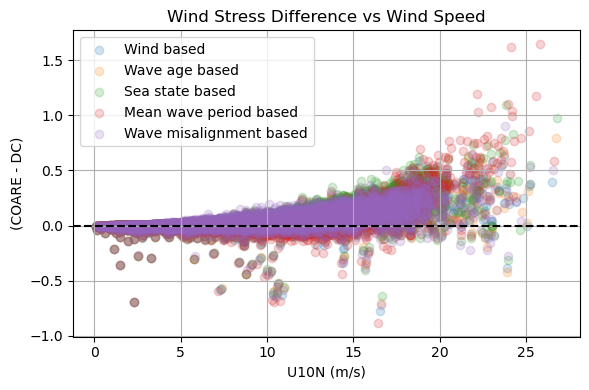

In [24]:
def plot_diff(x_name, xlab, title):
    
    fig, ax = plt.subplots(figsize=(6,4))
    
    for df, label in zip(dfs, labels):
        x = df[x_name]
        delta_tau = df['tau'] - cv_tau
        ax.scatter(x, delta_tau, alpha=0.2, label=label)
    
    ax.axhline(0, color='k', linestyle='--')
    ax.set_xlabel(xlab)
    ax.set_ylabel('(COARE - DC)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_diff('U10N', 'U10N (m/s)', 'Wind Stress Difference vs Wind Speed')



In [39]:
def binned_mean_plot(x, dfs, labels, cv_tau, xlabel, title, nbins=12):
    
    fig, ax = plt.subplots(figsize=(7,5))
    
    bins = pd.qcut(x, nbins, duplicates='drop')
    bin_centers = x.groupby(bins, observed=True).mean()
    
    for df, label in zip(dfs, labels):
        delta_tau = df['tau'] - cv_tau
        
        grouped = delta_tau.groupby(bins, observed=True)
        mean = grouped.mean()
        std = grouped.std()
        n = grouped.count()
        
        stderr = std / np.sqrt(n)
        
        ax.errorbar(bin_centers, mean, yerr=stderr, marker='o', capsize=3, label=label)
    
    ax.axhline(0, color='k', linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean Δτ (COARE - DC)')
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

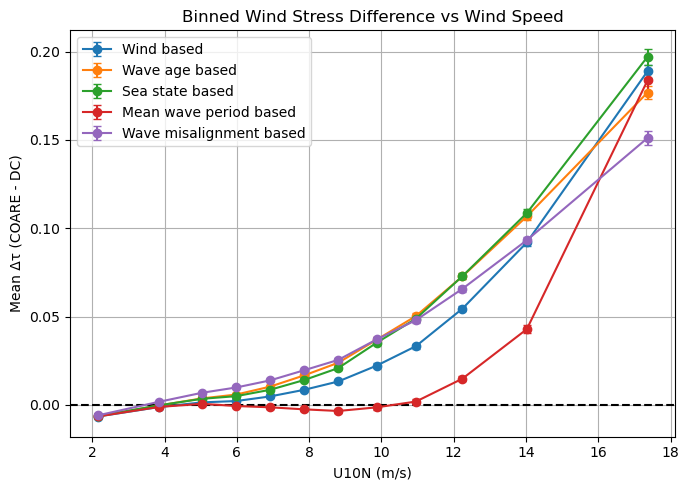

In [40]:
binned_mean_plot(
    wind['U10N'],
    dfs,
    labels,
    cv_tau,
    'U10N (m/s)',
    'Binned Wind Stress Difference vs Wind Speed'
)

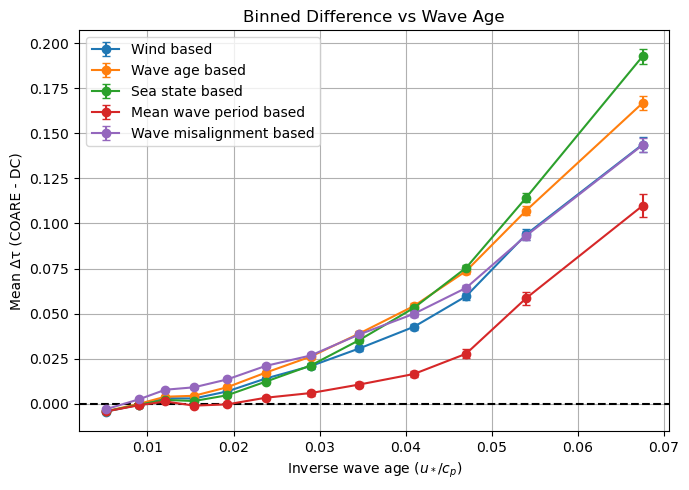

In [42]:
iwa = wind['usr'] / data['cp']

binned_mean_plot(
    iwa,
    dfs,
    labels,
    cv_tau,
    r'Inverse wave age ($u_*/c_p$)',
    'Binned Difference vs Wave Age'
)

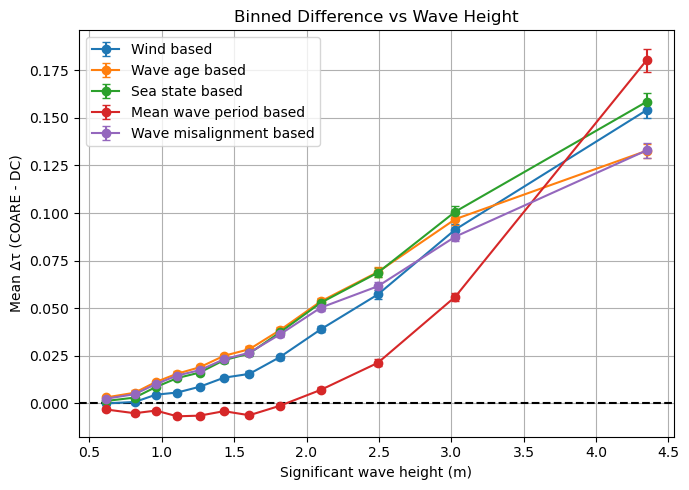

In [64]:
binned_mean_plot(
    data['sigH'],
    dfs,
    labels,
    cv_tau,
    'Significant wave height (m)',
    'Binned Difference vs Wave Height'
)

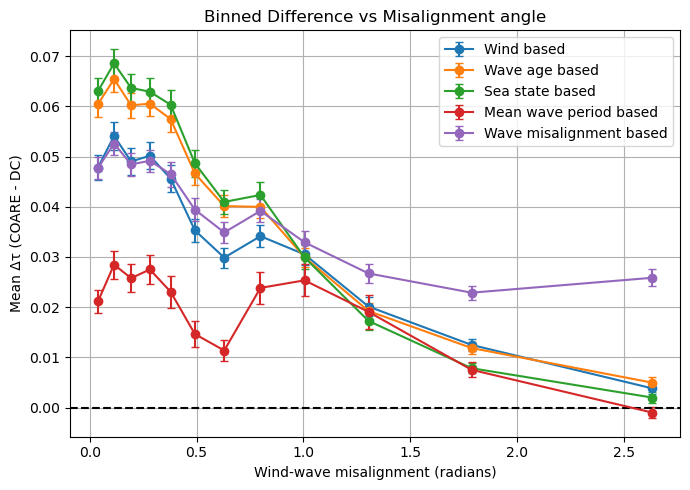

In [65]:
binned_mean_plot(
    pd.Series(theta),
    dfs,
    labels,
    cv_tau,
    'Wind-wave misalignment (radians)',
    'Binned Difference vs Misalignment angle'
)

<function matplotlib.pyplot.show(close=None, block=None)>

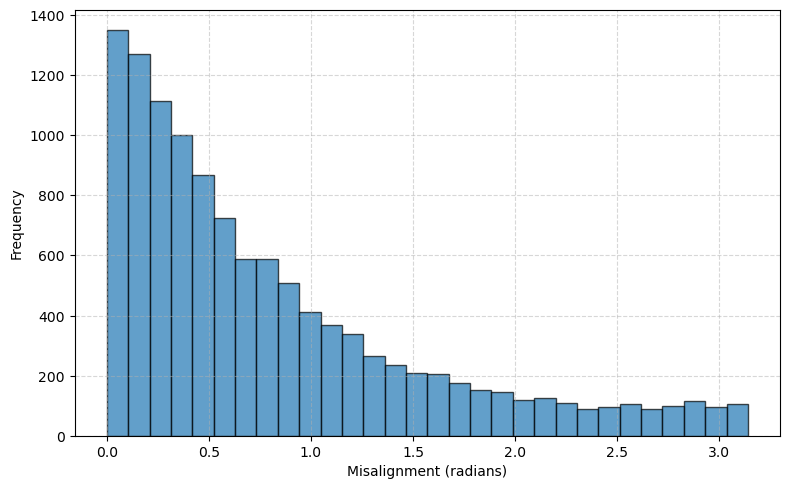

In [31]:
# Create histogram
plt.figure(figsize=(8,5))
plt.hist(theta, bins=30, edgecolor='black', alpha=0.7) 
plt.xlabel("Misalignment (radians)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('./PS1_figures/Gustiness_histogram.png')
plt.show

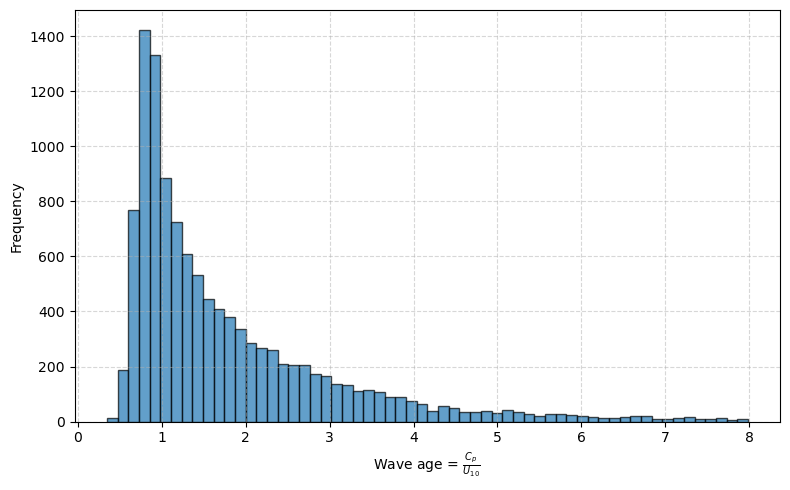

In [63]:
wave_age = data['cp'] / data['U10r']
wave_age = wave_age[wave_age < 8]  # include most data, ignore crazy outliers

plt.figure(figsize=(8,5))
plt.hist(wave_age, bins=60, edgecolor='black', alpha=0.7)
plt.xlabel(r"Wave age = $\frac{C_p}{U_{10}}$")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [61]:
wave_age = data['cp'] / data['U10r']
print(wave_age.describe())

count    11665.000000
mean         2.038567
std          2.889719
min          0.343051
25%          0.898668
50%          1.339621
75%          2.327429
max        162.049670
dtype: float64


In [47]:
eq12.columns

Index(['usr', 'tau', 'hsb', 'hlb', 'hbb', 'hsbb', 'hlwebb', 'tsr', 'qsr', 'zo',
       'zot', 'zoq', 'Cd', 'Ch', 'Ce', 'L', 'zeta', 'dT_skinx', 'dq_skinx',
       'dz_skin', 'Urf', 'Trf', 'Qrf', 'RHrf', 'UrfN', 'TrfN', 'QrfN',
       'lw_net', 'sw_net', 'Le', 'rhoa', 'UN', 'U10', 'U10N', 'Cdn_10',
       'Chn_10', 'Cen_10', 'hrain', 'Qs', 'Evap', 'T10', 'T10N', 'Q10', 'Q10N',
       'RH10', 'P10', 'rhoa10', 'gust', 'wc_frac', 'Edis', 'dT_warm',
       'dz_warm', 'dT_warm_to_skin', 'du_warm', 'time'],
      dtype='object')